### Import Required Libraries

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load the Three Dataset Files

In [40]:
train = pd.read_excel("C:\\Users\\rohit\\Downloads\\Data_Train.xlsx")
test = pd.read_excel("C:\\Users\\rohit\\Downloads\\Test_set.xlsx")
submission = pd.read_excel("C:\\Users\\rohit\\Downloads\\Sample_submission.xlsx")

### Check Dataset Size

In [41]:
print("Training Dataset Shape:", train.shape)
print("Test Dataset Shape:", test.shape)
print("Submission Dataset Shape:", submission.shape)

Training Dataset Shape: (10683, 11)
Test Dataset Shape: (2671, 10)
Submission Dataset Shape: (2671, 1)


### Display First 5 Rows

In [42]:
train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


### Check Column Names

In [43]:
train.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

### Data Types

In [44]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


### Check Missing Values

In [45]:
train.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

### Check Duplicate Rows

In [46]:
train.duplicated().sum()

np.int64(220)

### Remove Duplicates

In [47]:
train = train.drop_duplicates()

### Again Check Duplicate Rows

In [48]:
train.duplicated().sum()

np.int64(0)

### Handle Missing Values

In [49]:
train[train.isnull().any(axis=1)]

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
9039,Air India,6/05/2019,Delhi,Cochin,NaN,09:45,09:25 07 May,23h 40m,NaN,No info,7480


In [50]:
train = train.dropna()

train

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


### Check the Price Column

In [51]:
train["Price"].head()

0     3897
1     7662
2    13882
3     6218
4    13302
Name: Price, dtype: int64

### Check datatype

In [52]:
train["Price"].dtype

dtype('int64')

### Convert to numeric

In [53]:
train["Price"] = pd.to_numeric(
    train["Price"],
    errors="coerce"
)

train["Price"]

0         3897
1         7662
2        13882
3         6218
4        13302
         ...  
10678     4107
10679     4145
10680     7229
10681    12648
10682    11753
Name: Price, Length: 10462, dtype: int64

### Convert Date of Journey

In [54]:
train["Date_of_Journey"] = pd.to_datetime(
    train["Date_of_Journey"],
    dayfirst=True
)

train["Date_of_Journey"]

0       2019-03-24
1       2019-05-01
2       2019-06-09
3       2019-05-12
4       2019-03-01
           ...    
10678   2019-04-09
10679   2019-04-27
10680   2019-04-27
10681   2019-03-01
10682   2019-05-09
Name: Date_of_Journey, Length: 10462, dtype: datetime64[ns]

### Extract Day and Month

In [55]:
train["Journey_Day"] = train["Date_of_Journey"].dt.day
train["Journey_Month"] = train["Date_of_Journey"].dt.month

print(train["Journey_Day"])
print(train["Journey_Month"])

0        24
1         1
2         9
3        12
4         1
         ..
10678     9
10679    27
10680    27
10681     1
10682     9
Name: Journey_Day, Length: 10462, dtype: int32
0        3
1        5
2        6
3        5
4        3
        ..
10678    4
10679    4
10680    4
10681    3
10682    5
Name: Journey_Month, Length: 10462, dtype: int32


### Extract Departure Hour

In [58]:
train["Dep_Time"] = pd.to_datetime(
    train["Dep_Time"]
)
train["Dep_Time"]

0       2026-08-29 22:20:00
1       2026-08-29 05:50:00
2       2026-08-29 09:25:00
3       2026-08-29 18:05:00
4       2026-08-29 16:50:00
                ...        
10678   2026-08-29 19:55:00
10679   2026-08-29 20:45:00
10680   2026-08-29 08:20:00
10681   2026-08-29 11:30:00
10682   2026-08-29 10:55:00
Name: Dep_Time, Length: 10462, dtype: datetime64[ns]

In [59]:
train["Departure_Hour"] = train["Dep_Time"].dt.hour
train["Departure_Minute"] = train["Dep_Time"].dt.minute

print(train["Departure_Hour"])
print(train["Departure_Minute"])

0        22
1         5
2         9
3        18
4        16
         ..
10678    19
10679    20
10680     8
10681    11
10682    10
Name: Departure_Hour, Length: 10462, dtype: int32
0        20
1        50
2        25
3         5
4        50
         ..
10678    55
10679    45
10680    20
10681    30
10682    55
Name: Departure_Minute, Length: 10462, dtype: int32


### Create Departure Time Categories

In [60]:
def categorize_time(hour):

    if 0 <= hour < 6:
        return "Night"

    elif 6 <= hour < 12:
        return "Morning"

    elif 12 <= hour < 18:
        return "Afternoon"

    else:
        return "Evening"

In [61]:
train["Departure_Category"] = (
    train["Departure_Hour"]
    .apply(categorize_time)
)

train["Departure_Category"]

0          Evening
1            Night
2          Morning
3          Evening
4        Afternoon
           ...    
10678      Evening
10679      Evening
10680      Morning
10681      Morning
10682      Morning
Name: Departure_Category, Length: 10462, dtype: object

### Clean Duration

#### Extract hours

In [62]:
train["Duration_Hours"] = (
    train["Duration"]
    .str.extract(r"(\d+)h")
    .astype(float)
)

train["Duration_Hours"]

0         2.0
1         7.0
2        19.0
3         5.0
4         4.0
         ... 
10678     2.0
10679     2.0
10680     3.0
10681     2.0
10682     8.0
Name: Duration_Hours, Length: 10462, dtype: float64

#### Extract minutes

In [63]:
train["Duration_Minutes"] = (
    train["Duration"]
    .str.extract(r"(\d+)m")
    .astype(float)
)

train["Duration_Minutes"]

0        50.0
1        25.0
2         NaN
3        25.0
4        45.0
         ... 
10678    30.0
10679    35.0
10680     NaN
10681    40.0
10682    20.0
Name: Duration_Minutes, Length: 10462, dtype: float64

### Fill missing values

In [64]:
train["Duration_Hours"] = (
    train["Duration_Hours"].fillna(0)
)

train["Duration_Minutes"] = (
    train["Duration_Minutes"].fillna(0)
)

print(train["Duration_Hours"])
print(train["Duration_Minutes"])

0         2.0
1         7.0
2        19.0
3         5.0
4         4.0
         ... 
10678     2.0
10679     2.0
10680     3.0
10681     2.0
10682     8.0
Name: Duration_Hours, Length: 10462, dtype: float64
0        50.0
1        25.0
2         0.0
3        25.0
4        45.0
         ... 
10678    30.0
10679    35.0
10680     0.0
10681    40.0
10682    20.0
Name: Duration_Minutes, Length: 10462, dtype: float64


#### Create total minutes

In [65]:
train["Duration_Total_Minutes"] = (
    train["Duration_Hours"] * 60
    + train["Duration_Minutes"]
)

train["Duration_Total_Minutes"]

0         170.0
1         445.0
2        1140.0
3         325.0
4         285.0
          ...  
10678     150.0
10679     155.0
10680     180.0
10681     160.0
10682     500.0
Name: Duration_Total_Minutes, Length: 10462, dtype: float64

### Extract Number of Stops

In [66]:
stop_mapping = {
    "non-stop": 0,
    "1 stop": 1,
    "2 stops": 2,
    "3 stops": 3,
    "4 stops": 4
}

In [67]:
train["Stops_Count"] = (
    train["Total_Stops"]
    .map(stop_mapping)
)

train["Stops_Count"] 

0        0
1        2
2        2
3        1
4        1
        ..
10678    0
10679    0
10680    0
10681    0
10682    2
Name: Stops_Count, Length: 10462, dtype: int64

### Create Route Name

In [68]:
train["Route_Name"] = (
    train["Source"]
    + " → "
    + train["Destination"]
)

train["Route_Name"]

0        Banglore → New Delhi
1          Kolkata → Banglore
2              Delhi → Cochin
3          Kolkata → Banglore
4        Banglore → New Delhi
                 ...         
10678      Kolkata → Banglore
10679      Kolkata → Banglore
10680        Banglore → Delhi
10681    Banglore → New Delhi
10682          Delhi → Cochin
Name: Route_Name, Length: 10462, dtype: object

### Save Cleaned Dataset

In [69]:
train.to_csv(
    "flight_train_cleaned.csv",
    index=False
)

### EDA — Airline with Highest Average Price

In [70]:
airline_avg_price = (
    train.groupby("Airline")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(airline_avg_price)

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11599.021081
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9556.608028
Vistara Premium economy               8962.333333
Vistara                               7801.355649
GoAir                                 5861.056701
IndiGo                                5668.469897
Air Asia                              5590.260188
SpiceJet                              4335.841718
Trujet                                4140.000000
Name: Price, dtype: float64


### Visualization

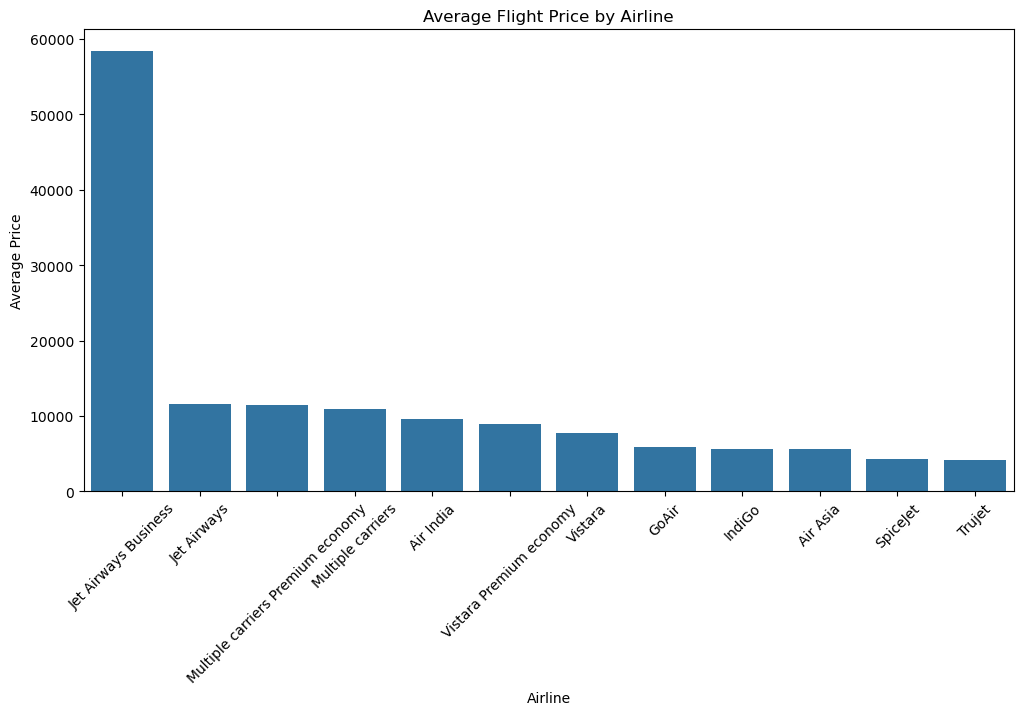

In [71]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=airline_avg_price.index,
    y=airline_avg_price.values
)

plt.xticks(rotation=45)

plt.title("Average Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price")

plt.show()

### Non-Stop vs Connecting Flights

In [72]:
train["Flight_Type"] = train["Total_Stops"].apply(
    lambda x: "Non-Stop" if x == 0 else "Connecting"
)

train["Flight_Type"]

0        Connecting
1        Connecting
2        Connecting
3        Connecting
4        Connecting
            ...    
10678    Connecting
10679    Connecting
10680    Connecting
10681    Connecting
10682    Connecting
Name: Flight_Type, Length: 10462, dtype: object

In [73]:
flight_type_price = (
    train.groupby("Flight_Type")["Price"]
    .mean()
)

print(flight_type_price)

Flight_Type
Connecting    9026.790289
Name: Price, dtype: float64


### Most Expensive Routes

In [74]:
route_avg_price = (
    train.groupby("Route")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(route_avg_price.head(10))

Route
BOM → DED → DEL → HYD                24115.000000
BOM → JDH → DEL → HYD                23867.000000
BOM → VNS → DEL → HYD                23528.000000
BOM → UDR → DEL → HYD                22950.000000
BOM → BDQ → DEL → HYD                22792.500000
DEL → DED → BOM → COK                19539.500000
DEL → IXU → BOM → COK                19381.333333
BOM → JDH → JAI → DEL → HYD          18293.000000
BOM → JAI → DEL → HYD                17926.000000
BLR → CCU → BBI → HYD → VGA → DEL    17686.000000
Name: Price, dtype: float64


### Visualization

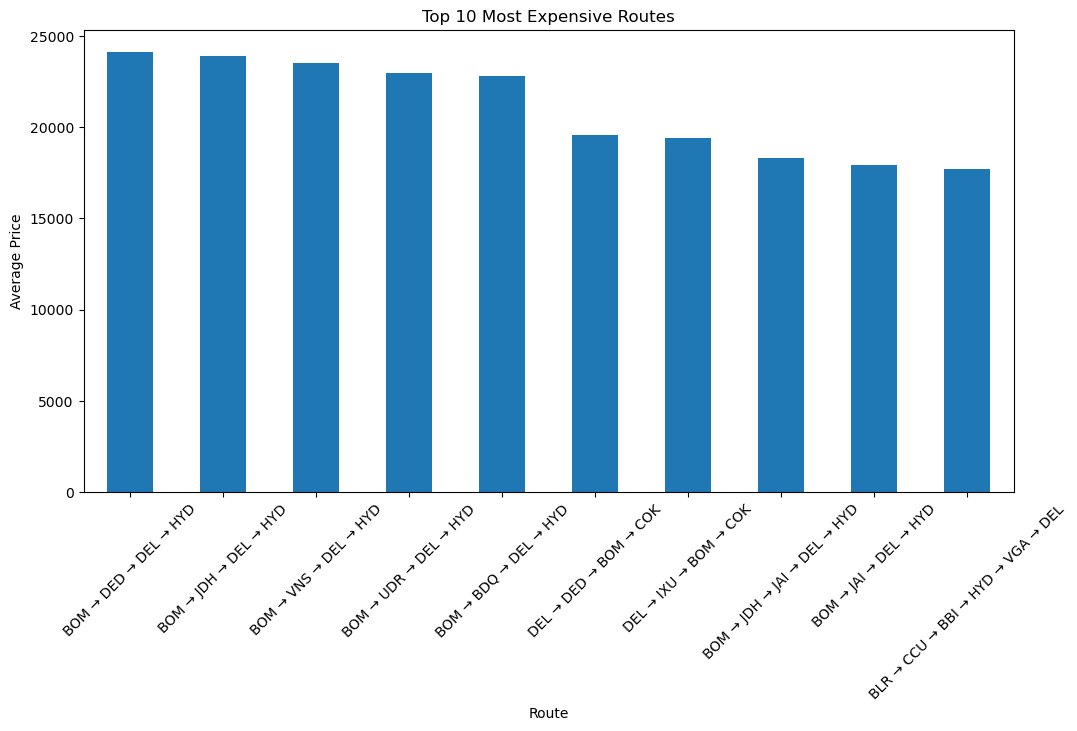

In [75]:
route_avg_price.head(10).plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Top 10 Most Expensive Routes")
plt.xlabel("Route")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.show()

### Duration vs Price

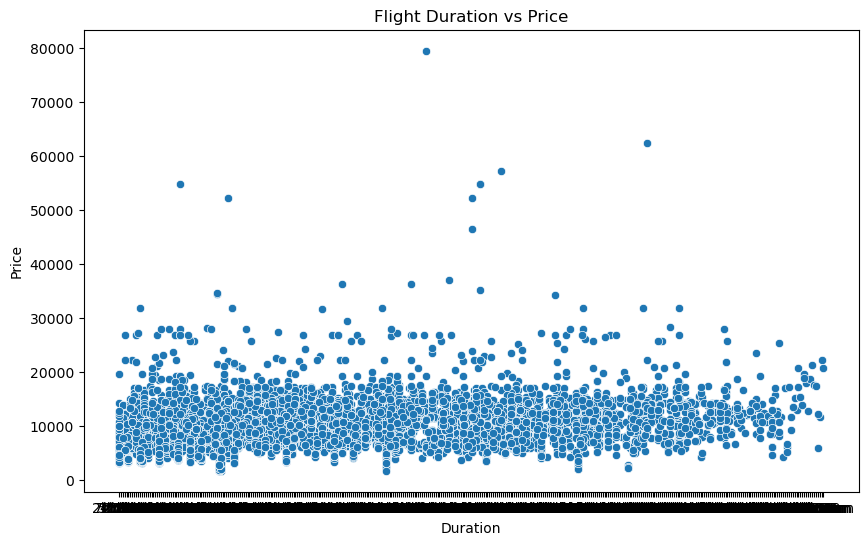

In [76]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train,
    x="Duration",
    y="Price"
)

plt.title("Flight Duration vs Price")

plt.show()

###  Correlation

In [78]:
correlation = train[
    ["Duration_Total_Minutes", "Stops_Count", "Price"]
].corr()

print(correlation)

                        Duration_Total_Minutes  Stops_Count     Price
Duration_Total_Minutes                1.000000     0.727982  0.501758
Stops_Count                           0.727982     1.000000  0.602013
Price                                 0.501758     0.602013  1.000000


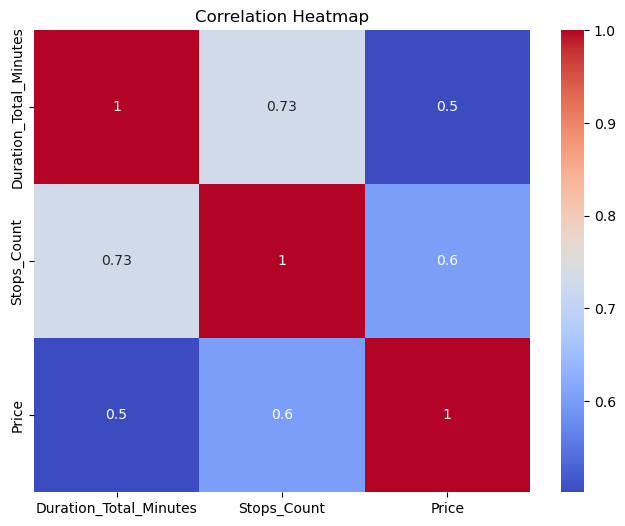

In [79]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

### Departure Time vs Price

In [80]:
departure_price = (
    train.groupby("Departure_Category")["Price"]
    .mean()
)

print(departure_price)

Departure_Category
Afternoon    9176.259462
Evening      8905.075694
Morning      9093.728930
Night        8696.149140
Name: Price, dtype: float64


### Visualization

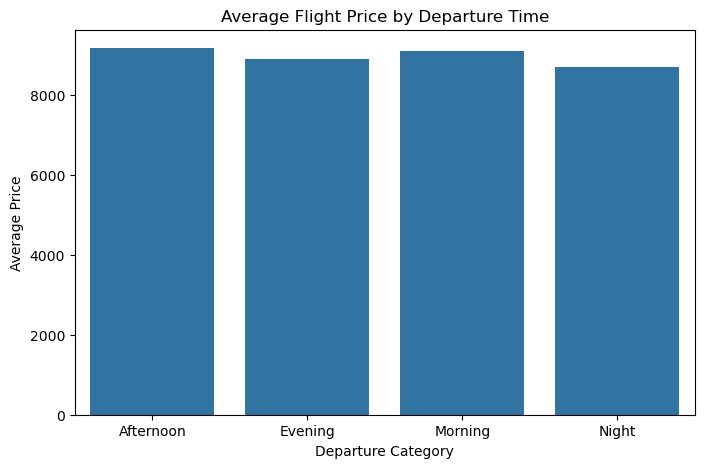

In [81]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=departure_price.index,
    y=departure_price.values
)

plt.title("Average Flight Price by Departure Time")

plt.xlabel("Departure Category")
plt.ylabel("Average Price")

plt.show()

### Price Distribution

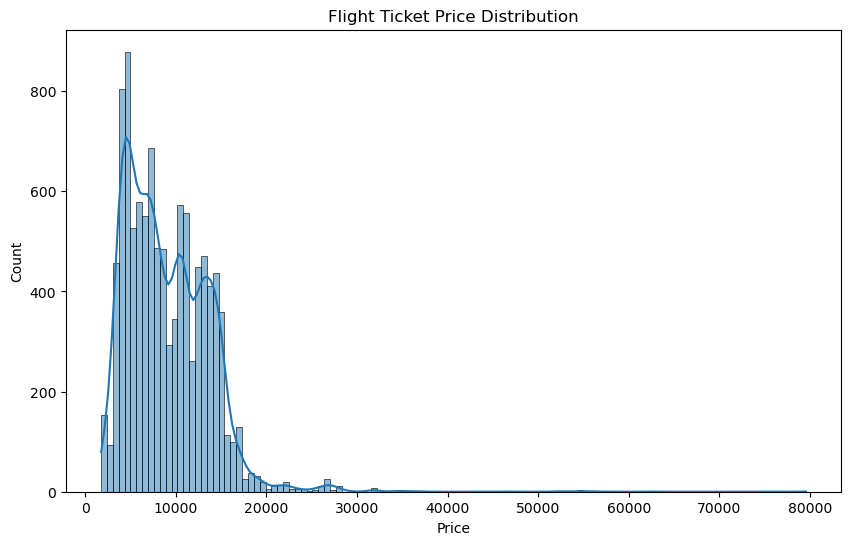

In [82]:
plt.figure(figsize=(10, 6))

sns.histplot(
    train["Price"],
    kde=True
)

plt.title("Flight Ticket Price Distribution")

plt.show()

### Airline Price Comparison

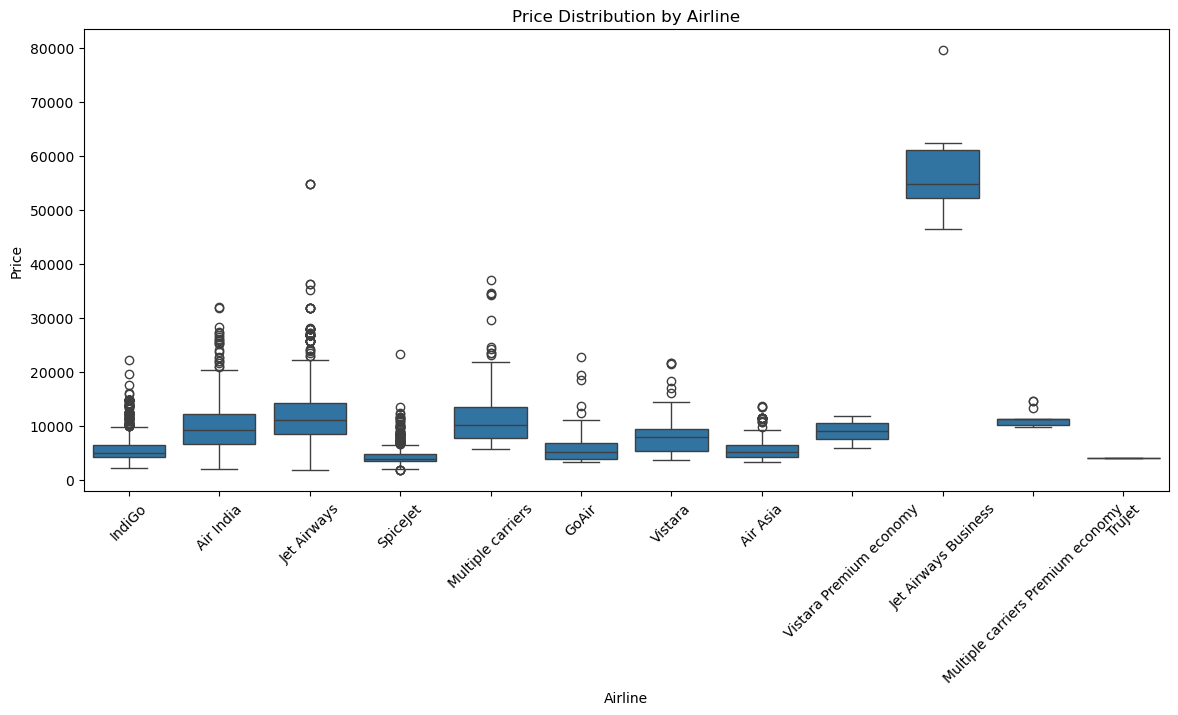

In [83]:
plt.figure(figsize=(14, 6))

sns.boxplot(
    data=train,
    x="Airline",
    y="Price"
)

plt.xticks(rotation=45)

plt.title("Price Distribution by Airline")

plt.show()

## Final Project Conclusion

##### The Flight Price & Airline Analysis project analyzed various factors influencing airline ticket prices. The dataset was cleaned by handling missing values, removing duplicate records, converting date and time columns, extracting flight duration, and converting the number of stops into numerical format. Exploratory Data Analysis was then performed to examine the relationship between airline, route, duration, number of  stops, and departure timing with ticket prices. The results provide useful insights into the major factors associated with flight price variation.

## STEP 1 — Dataset Understanding

### 1.1 Import Libraries

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 1.2 Check Dataset Shape

In [86]:
print("Train Dataset Shape:", train.shape)
print("Test Dataset Shape:", test.shape)

Train Dataset Shape: (10462, 22)
Test Dataset Shape: (2671, 10)


### 1.3 Display First 5 Rows

In [87]:
train.head()

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Journey_Month,Departure_Hour,Departure_Minute,Departure_Category,Duration_Hours,Duration_Minutes,Duration_Total_Minutes,Stops_Count,Route_Name,Flight_Type
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,2026-08-29 22:20:00,01:10 22 Mar,2h 50m,non-stop,No info,...,3,22,20,Evening,2.0,50.0,170.0,0,Banglore → New Delhi,Connecting
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,2026-08-29 05:50:00,13:15,7h 25m,2 stops,No info,...,5,5,50,Night,7.0,25.0,445.0,2,Kolkata → Banglore,Connecting
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,2026-08-29 09:25:00,04:25 10 Jun,19h,2 stops,No info,...,6,9,25,Morning,19.0,0.0,1140.0,2,Delhi → Cochin,Connecting
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,2026-08-29 18:05:00,23:30,5h 25m,1 stop,No info,...,5,18,5,Evening,5.0,25.0,325.0,1,Kolkata → Banglore,Connecting
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,2026-08-29 16:50:00,21:35,4h 45m,1 stop,No info,...,3,16,50,Afternoon,4.0,45.0,285.0,1,Banglore → New Delhi,Connecting


#### 1.4 Check All Column Names

In [88]:
print(train.columns.tolist())

['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route', 'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price', 'Journey_Day', 'Journey_Month', 'Departure_Hour', 'Departure_Minute', 'Departure_Category', 'Duration_Hours', 'Duration_Minutes', 'Duration_Total_Minutes', 'Stops_Count', 'Route_Name', 'Flight_Type']


### 1.5 Understand Each Column

#### 1.6 Check Data Types and Missing Values


In [89]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Airline                 10462 non-null  object        
 1   Date_of_Journey         10462 non-null  datetime64[ns]
 2   Source                  10462 non-null  object        
 3   Destination             10462 non-null  object        
 4   Route                   10462 non-null  object        
 5   Dep_Time                10462 non-null  datetime64[ns]
 6   Arrival_Time            10462 non-null  object        
 7   Duration                10462 non-null  object        
 8   Total_Stops             10462 non-null  object        
 9   Additional_Info         10462 non-null  object        
 10  Price                   10462 non-null  int64         
 11  Journey_Day             10462 non-null  int32         
 12  Journey_Month           10462 non-null  int32      

### 1.7 Statistical Summary

In [90]:
train.describe()

,Date_of_Journey,Dep_Time,Price,Journey_Day,Journey_Month,Departure_Hour,Departure_Minute,Duration_Hours,Duration_Minutes,Duration_Total_Minutes,Stops_Count
count,10462,10462,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000,10462.000000
mean,2019-05-04 13:38:33.056776960,2026-08-29 12:53:06.876314112,9026.790289,13.463200,4.701491,12.478494,24.404989,10.026190,28.210189,629.781591,0.802332
min,2019-03-01 00:00:00,2026-08-29 00:20:00,1759.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000
25%,2019-03-27 00:00:00,2026-08-29 08:00:00,5224.000000,6.000000,3.000000,8.000000,5.000000,2.000000,15.000000,170.000000,0.000000
50%,2019-05-15 00:00:00,2026-08-29 11:45:00,8266.000000,12.000000,5.000000,11.000000,25.000000,8.000000,30.000000,505.000000,1.000000
75%,2019-06-06 00:00:00,2026-08-29 18:00:00,12344.750000,21.000000,6.000000,18.000000,40.000000,15.000000,45.000000,910.000000,1.000000
max,2019-06-27 00:00:00,2026-08-29 23:55:00,79512.000000,27.000000,6.000000,23.000000,55.000000,47.000000,55.000000,2860.000000,4.000000
std,NaN,NaN,4624.849541,8.467493,1.163802,5.727227,18.815719,8.378023,16.879185,500.699045,0.660609


### 1.8 Check Missing Values

In [94]:
train.isnull().sum()

Airline                   0
Date_of_Journey           0
Source                    0
Destination               0
Route                     0
Dep_Time                  0
Arrival_Time              0
Duration                  0
Total_Stops               0
Additional_Info           0
Price                     0
Journey_Day               0
Journey_Month             0
Departure_Hour            0
Departure_Minute          0
Departure_Category        0
Duration_Hours            0
Duration_Minutes          0
Duration_Total_Minutes    0
Stops_Count               0
Route_Name                0
Flight_Type               0
dtype: int64

#### 1.10 Check Duplicate Rows

In [95]:
print("Duplicate Rows:", train.duplicated().sum())

Duplicate Rows: 0


### 1.11  Check Unique Values in Important Columns

##### Airlines

In [96]:
print("Number of Airlines:", train["Airline"].nunique())

print(train["Airline"].unique())

Number of Airlines: 12
['IndiGo' 'Air India' 'Jet Airways' 'SpiceJet' 'Multiple carriers' 'GoAir'
 'Vistara' 'Air Asia' 'Vistara Premium economy' 'Jet Airways Business'
 'Multiple carriers Premium economy' 'Trujet']


##### Source Cities

In [97]:
print(train["Source"].unique())

['Banglore' 'Kolkata' 'Delhi' 'Chennai' 'Mumbai']


##### Destination Cities

In [98]:
print(train["Destination"].unique())

['New Delhi' 'Banglore' 'Cochin' 'Kolkata' 'Delhi' 'Hyderabad']


#### Total Stops

### Check Basic Price Informatio

In [99]:
print("Minimum Price:", train["Price"].min())
print("Maximum Price:", train["Price"].max())
print("Average Price:", train["Price"].mean())
print("Median Price:", train["Price"].median())

Minimum Price: 1759
Maximum Price: 79512
Average Price: 9026.790288663735
Median Price: 8266.0


## STEP 2 — Data Cleaning

### final summary

In [100]:
print("=" * 50)
print("DATASET SUMMARY")
print("=" * 50)

print("\nShape:")
print(train.shape)

print("\nData Types:")
print(train.dtypes)

print("\nMissing Values:")
print(train.isnull().sum())

print("\nDuplicate Rows:")
print(train.duplicated().sum())

print("\nPrice Statistics:")
print(train["Price"].describe())

DATASET SUMMARY

Shape:
(10462, 22)

Data Types:
Airline                           object
Date_of_Journey           datetime64[ns]
Source                            object
Destination                       object
Route                             object
Dep_Time                  datetime64[ns]
Arrival_Time                      object
Duration                          object
Total_Stops                       object
Additional_Info                   object
Price                              int64
Journey_Day                        int32
Journey_Month                      int32
Departure_Hour                     int32
Departure_Minute                   int32
Departure_Category                object
Duration_Hours                   float64
Duration_Minutes                 float64
Duration_Total_Minutes           float64
Stops_Count                        int64
Route_Name                        object
Flight_Type                       object
dtype: object

Missing Values:
Airline           

## STEP 3 — Exploratory Data Analysis (EDA)

### EDA 1: Airline-wise Flight Price Analysis

### Step 3.1 — Calculate Average Price by Airline

In [101]:
airline_avg_price = (
    train.groupby("Airline")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(airline_avg_price)

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11599.021081
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9556.608028
Vistara Premium economy               8962.333333
Vistara                               7801.355649
GoAir                                 5861.056701
IndiGo                                5668.469897
Air Asia                              5590.260188
SpiceJet                              4335.841718
Trujet                                4140.000000
Name: Price, dtype: float64


### Step 3.2 — Create Airline Price Chart

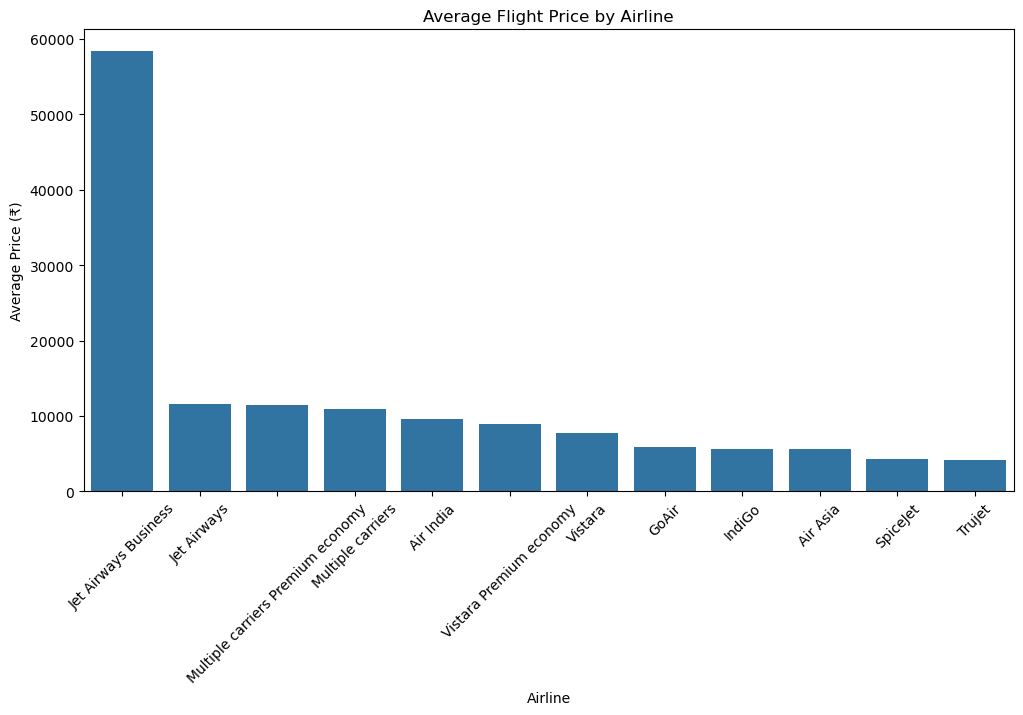

In [102]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=airline_avg_price.index,
    y=airline_avg_price.values
)

plt.title("Average Flight Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price (₹)")

plt.xticks(rotation=45)

plt.show()

### Extra Analysis: Number of Flights by Airline

In [103]:
airline_count = train["Airline"].value_counts()

print(airline_count)

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64


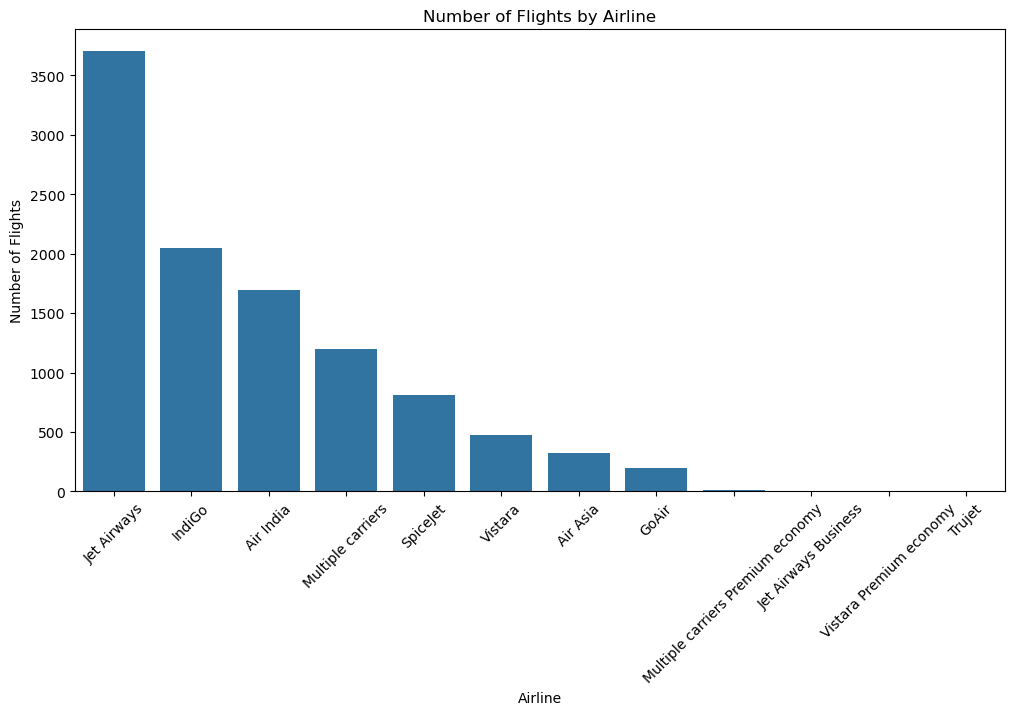

In [104]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=train,
    x="Airline",
    order=train["Airline"].value_counts().index
)

plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Number of Flights")

plt.xticks(rotation=45)

plt.show()

### Average Price by Airline

In [105]:
print(airline_avg_price)

Airline
Jet Airways Business                 58358.666667
Jet Airways                          11599.021081
Multiple carriers Premium economy    11418.846154
Multiple carriers                    10902.678094
Air India                             9556.608028
Vistara Premium economy               8962.333333
Vistara                               7801.355649
GoAir                                 5861.056701
IndiGo                                5668.469897
Air Asia                              5590.260188
SpiceJet                              4335.841718
Trujet                                4140.000000
Name: Price, dtype: float64


### Number of Flights by Airline

In [106]:
print(train["Airline"].value_counts())

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64


## EDA 2 — Non-Stop vs Connecting Flights

In [113]:
train["Flight_Type"] = train["Total_Stops"].apply(
    lambda x: "Non-Stop" if x == "non-stop" else "Connecting"
)

In [114]:
print(train["Flight_Type"].value_counts())

Flight_Type
Connecting    6987
Non-Stop      3475
Name: count, dtype: int64


### Step 1: Calculate the average price

In [115]:
flight_type_price = (
    train.groupby("Flight_Type")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(flight_type_price)

Flight_Type
Connecting    11020.319021
Non-Stop       5018.506763
Name: Price, dtype: float64


### Step 2: Create the chart

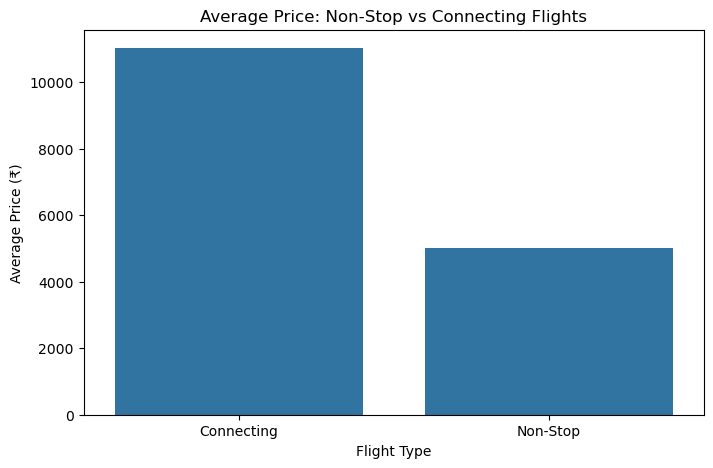

In [116]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=flight_type_price.index,
    y=flight_type_price.values
)

plt.title("Average Price: Non-Stop vs Connecting Flights")
plt.xlabel("Flight Type")
plt.ylabel("Average Price (₹)")

plt.show()

### EDA 3 — Which Routes Are Expensive?

### Step 1: Calculate average price by route

In [117]:
route_avg_price = (
    train.groupby("Route_Name")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(route_avg_price)

Route_Name
Banglore → New Delhi    12007.421225
Delhi → Cochin          10461.600690
Kolkata → Banglore       9143.083566
Banglore → Delhi         5143.918577
Mumbai → Hyderabad       5059.708752
Chennai → Kolkata        4789.892388
Name: Price, dtype: float64


### Step 2: Show Top 10 Expensive Routes

In [118]:
print(route_avg_price.head(10))

Route_Name
Banglore → New Delhi    12007.421225
Delhi → Cochin          10461.600690
Kolkata → Banglore       9143.083566
Banglore → Delhi         5143.918577
Mumbai → Hyderabad       5059.708752
Chennai → Kolkata        4789.892388
Name: Price, dtype: float64


### Step 3: Create a Bar Chart

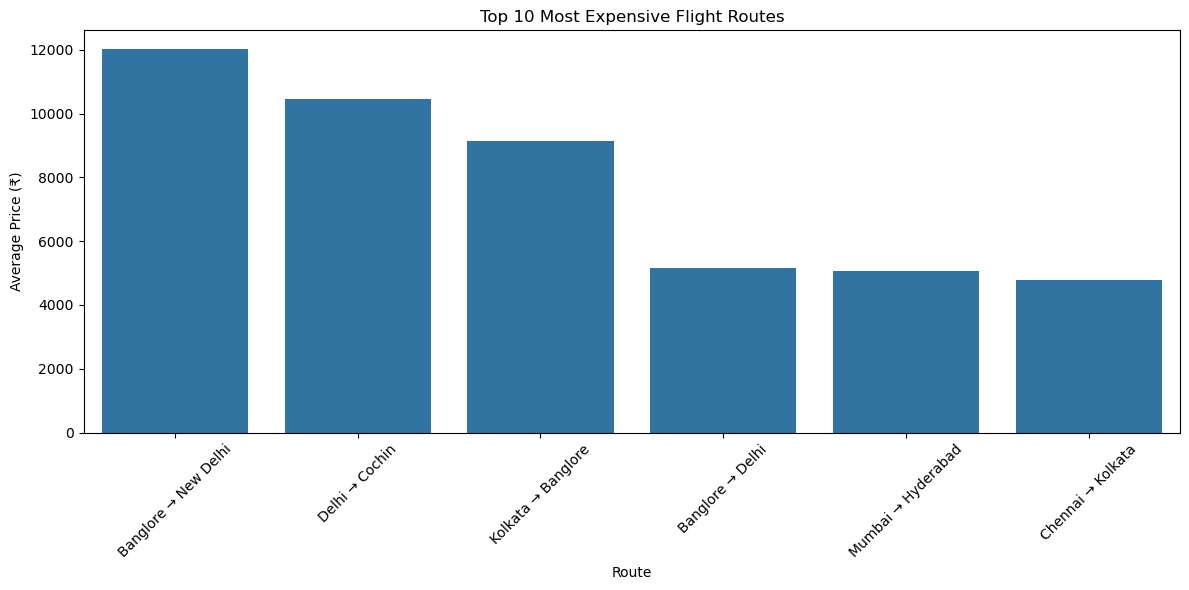

In [119]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=route_avg_price.head(10).index,
    y=route_avg_price.head(10).values
)

plt.title("Top 10 Most Expensive Flight Routes")
plt.xlabel("Route")
plt.ylabel("Average Price (₹)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [120]:
print(route_avg_price.head(10))

Route_Name
Banglore → New Delhi    12007.421225
Delhi → Cochin          10461.600690
Kolkata → Banglore       9143.083566
Banglore → Delhi         5143.918577
Mumbai → Hyderabad       5059.708752
Chennai → Kolkata        4789.892388
Name: Price, dtype: float64


### EDA 4 — Does Flight Duration Affect Price

### Step 1: Check the relationship using correlation

In [121]:
duration_price_corr = train[
    ["Duration_Total_Minutes", "Price"]
].corr()

print(duration_price_corr)

                        Duration_Total_Minutes     Price
Duration_Total_Minutes                1.000000  0.501758
Price                                 0.501758  1.000000


### Step 2: Create a Scatter Plot

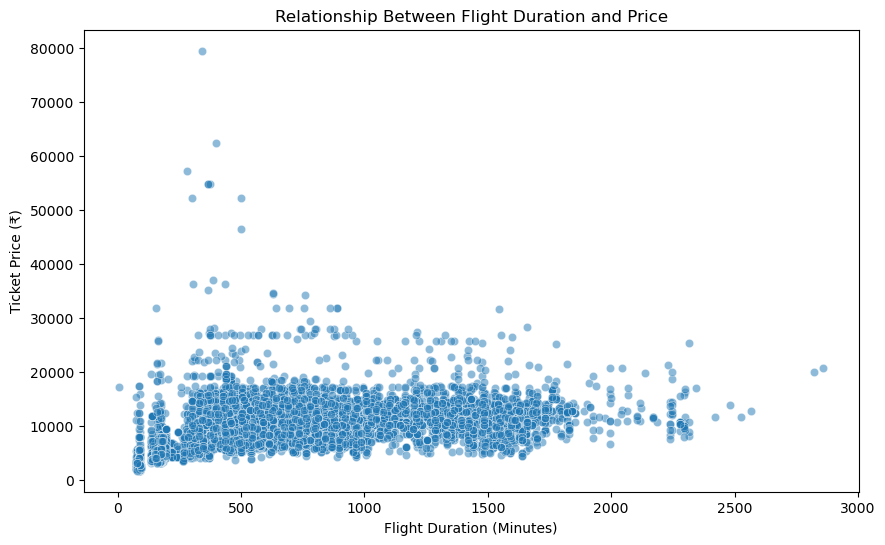

In [122]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train,
    x="Duration_Total_Minutes",
    y="Price",
    alpha=0.5
)

plt.title("Relationship Between Flight Duration and Price")
plt.xlabel("Flight Duration (Minutes)")
plt.ylabel("Ticket Price (₹)")

plt.show()

### Step 3:  — Add a Trend Line

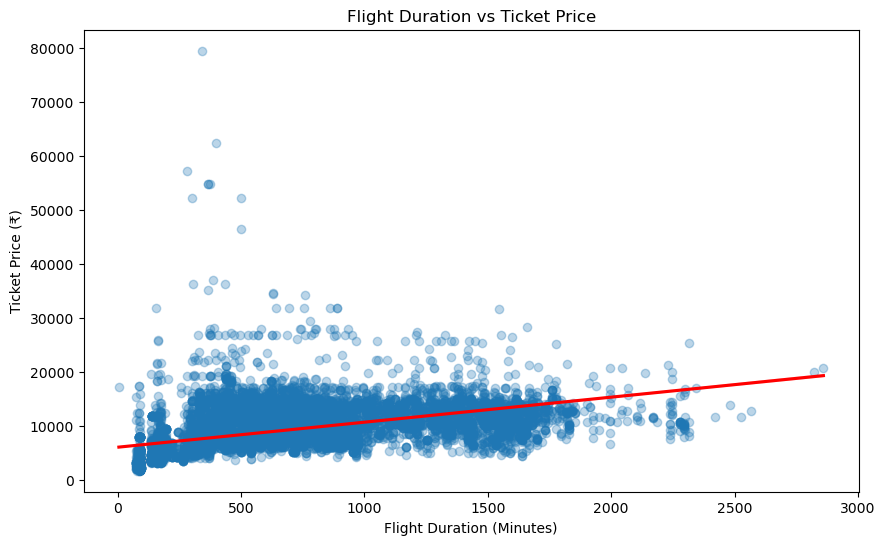

In [123]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=train,
    x="Duration_Total_Minutes",
    y="Price",
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Flight Duration vs Ticket Price")
plt.xlabel("Flight Duration (Minutes)")
plt.ylabel("Ticket Price (₹)")

plt.show()

In [124]:
print(duration_price_corr)

                        Duration_Total_Minutes     Price
Duration_Total_Minutes                1.000000  0.501758
Price                                 0.501758  1.000000


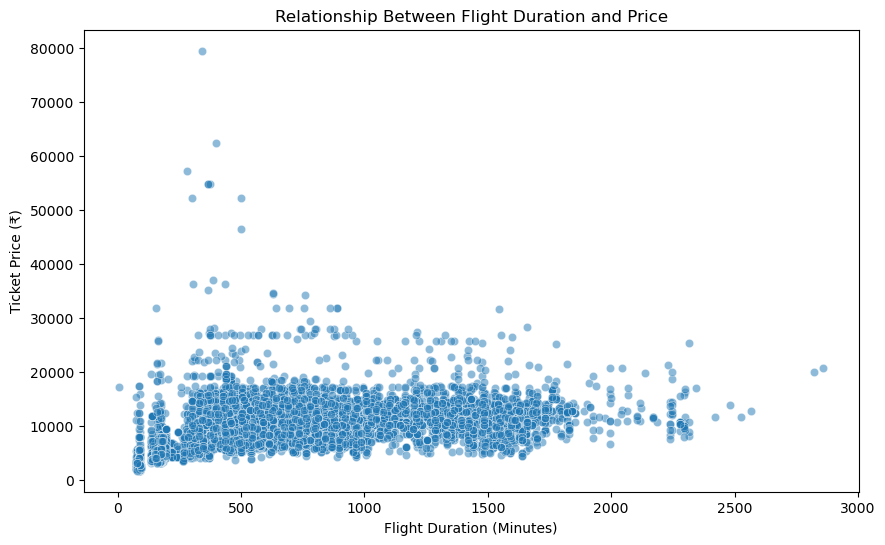

In [125]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train,
    x="Duration_Total_Minutes",
    y="Price",
    alpha=0.5
)

plt.title("Relationship Between Flight Duration and Price")
plt.xlabel("Flight Duration (Minutes)")
plt.ylabel("Ticket Price (₹)")

plt.show()

### EDA 5 — Which Departure Times Have Higher Prices

### Step 1: Calculate Average Price by Departure Category

In [126]:
departure_price = (
    train.groupby("Departure_Category")["Price"]
    .mean()
    .sort_values(ascending=False)
)

print(departure_price)

Departure_Category
Afternoon    9176.259462
Morning      9093.728930
Evening      8905.075694
Night        8696.149140
Name: Price, dtype: float64


### Step 2: Create the Chart

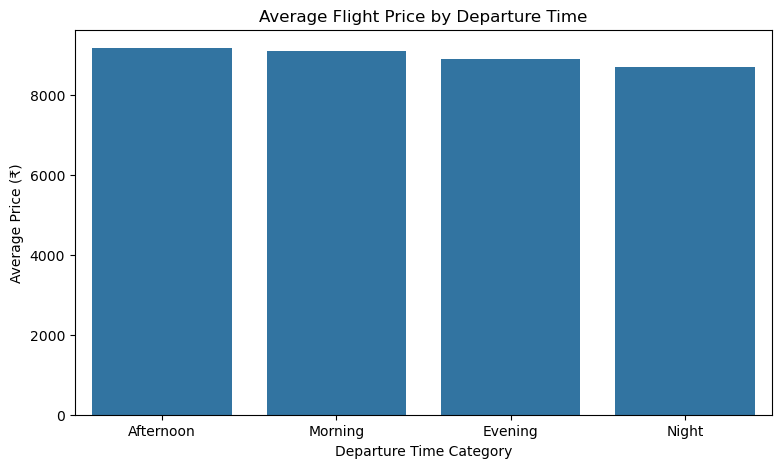

In [127]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=departure_price.index,
    y=departure_price.values
)

plt.title("Average Flight Price by Departure Time")
plt.xlabel("Departure Time Category")
plt.ylabel("Average Price (₹)")

plt.show()

In [128]:
print(departure_price)

Departure_Category
Afternoon    9176.259462
Morning      9093.728930
Evening      8905.075694
Night        8696.149140
Name: Price, dtype: float64


## STEP 4 — Correlation Heatmap

In [129]:
numeric_columns = [
    "Journey_Day",
    "Journey_Month",
    "Departure_Hour",
    "Departure_Minute",
    "Duration_Total_Minutes",
    "Stops_Count",
    "Price"
]

correlation_matrix = train[numeric_columns].corr()

print(correlation_matrix)

                        Journey_Day  Journey_Month  Departure_Hour  \
Journey_Day                1.000000      -0.038331       -0.003394   
Journey_Month             -0.038331       1.000000        0.040406   
Departure_Hour            -0.003394       0.040406        1.000000   
Departure_Minute          -0.004741      -0.062636       -0.015068   
Duration_Total_Minutes    -0.029810       0.004874       -0.001285   
Stops_Count               -0.018937       0.039003       -0.067523   
Price                     -0.159044      -0.113396        0.005155   

                        Departure_Minute  Duration_Total_Minutes  Stops_Count  \
Journey_Day                    -0.004741               -0.029810    -0.018937   
Journey_Month                  -0.062636                0.004874     0.039003   
Departure_Hour                 -0.015068               -0.001285    -0.067523   
Departure_Minute                1.000000               -0.019225    -0.002695   
Duration_Total_Minutes         -0.

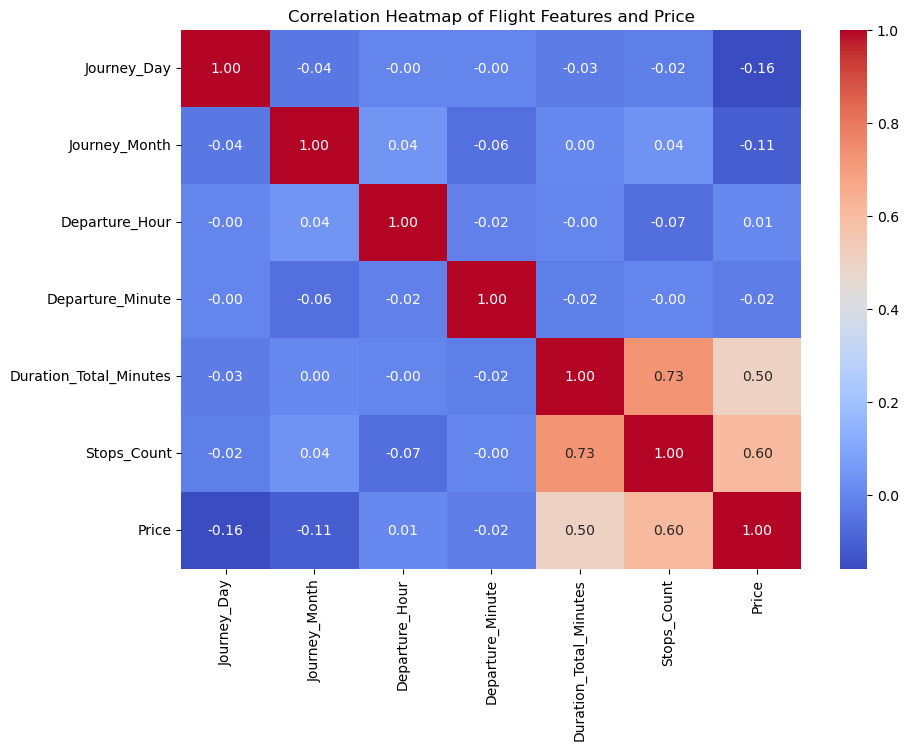

In [130]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Flight Features and Price")

plt.show()

## STEP 5 — Save Your Final Cleaned Dataset

In [131]:
train.to_csv(
    "Flight_Price_Cleaned_Final.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## STEP 6 — Final Key Findings

### 1. Airline

##### Jet Airways Business had the highest average ticket price at approximately ₹58,358.67.

### 2. Flight Type

#### Connecting flights had a higher average price (₹11,020.32) than non-stop flights (₹5,018.51) in this dataset.

### 3. Route

#### Banglore → New Delhi was the most expensive route, with an average ticket price of approximately ₹12,007.42.

### 4. Duration

#### Flight duration had a moderate positive correlation of 0.50 with ticket price, suggesting that longer flights generally tended to cost more.

### 5. Departure Time

#### Afternoon flights had the highest average price (₹9,176.26), followed closely by morning flights.

## STEP 7 — Final Conclusion

### Conclusion

##### The Flight Price & Airline Analysis project examined the factors influencing airline ticket prices using flight data containing information about airlines, routes, departure times, flight duration, number of stops, and ticket prices.

##### The dataset was cleaned by removing duplicate records, handling missing values, converting date and time columns into appropriate formats, extracting flight duration into numerical values, and converting the number of stops into a numerical format. Additional features such as journey day, journey month, departure hour, departure category, route name, and flight type were created to support further analysis.

##### The exploratory data analysis showed that airline choice has a significant association with ticket prices. Jet Airways Business had the highest average ticket price among the airlines in the dataset. Connecting flights had a higher average ticket price than non-stop flights in the available data. Route analysis showed that the Banglore to New Delhi route had the highest average ticket price.

##### The relationship between flight duration and ticket price showed a moderate positive correlation of approximately 0.50, indicating that longer flights generally tend to have higher prices. Departure time analysis showed that afternoon flights had the highest average ticket prices, although the differences between departure time categories were moderate.

##### Overall, the analysis demonstrates that flight ticket prices are influenced by multiple factors, including airline, route, number of stops, flight duration, and departure timing. These findings can help travelers and businesses better understand patterns in airline ticket pricing.
